In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/credit_card_fraud_10k.csv")
print("Dataset shape:", df.shape)

Dataset shape: (10000, 10)


In [3]:
X = df.drop(columns=["is_fraud", "transaction_id"])
y = df["is_fraud"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Features:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']

Target:
is_fraud

X shape: (10000, 8)
y shape: (10000,)


In [4]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)


X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

X_train: (7000, 8)
X_val: (1500, 8)
X_test: (1500, 8)
y_train: (7000,)
y_val: (1500,)
y_test: (1500,)


In [5]:
encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

X_train_cat = encoder.fit_transform(
    X_train[["merchant_category"]]
)

X_val_cat = encoder.transform(
    X_val[["merchant_category"]]
)

X_test_cat = encoder.transform(
    X_test[["merchant_category"]]
)

print("X_train_cat:", X_train_cat.shape)
print("X_val_cat:", X_val_cat.shape)
print("X_test_cat:", X_test_cat.shape)

X_train_cat: (7000, 5)
X_val_cat: (1500, 5)
X_test_cat: (1500, 5)


In [6]:
categorical_features = ["merchant_category"]
numerical_features = [
    "amount",
    "transaction_hour",
    "foreign_transaction",
    "location_mismatch",
    "device_trust_score",
    "velocity_last_24h",
    "cardholder_age"
]

In [7]:
scaler = StandardScaler()

X_train_num = scaler.fit_transform(
    X_train[numerical_features]
)

X_val_num = scaler.transform(
    X_val[numerical_features]
)

X_test_num = scaler.transform(
    X_test[numerical_features]
)

print("X_train_num:", X_train_num.shape)
print("X_val_num:", X_val_num.shape)
print("X_test_num:", X_test_num.shape)

X_train_num: (7000, 7)
X_val_num: (1500, 7)
X_test_num: (1500, 7)


In [8]:
X_train_processed = np.hstack([
    X_train_num,
    X_train_cat
])

X_val_processed = np.hstack([
    X_val_num,
    X_val_cat
])

X_test_processed = np.hstack([
    X_test_num,
    X_test_cat
])

print("X_train_processed:", X_train_processed.shape)
print("X_val_processed:", X_val_processed.shape)
print("X_test_processed:", X_test_processed.shape)

X_train_processed: (7000, 12)
X_val_processed: (1500, 12)
X_test_processed: (1500, 12)


## 1. Logistic Regression — Baseline

In [9]:
lr_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_baseline.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [10]:
y_val_prob = lr_baseline.predict_proba(X_val_processed)[:, 1]

In [11]:
y_val_pred = (y_val_prob >= 0.5).astype(int)

In [12]:
cm_lr_baseline = confusion_matrix(y_val, y_val_pred)

print("Confusion Matrix:")
print(cm_lr_baseline)

print("Classification Report:")
print(classification_report(y_val, y_val_pred))

Confusion Matrix:
[[1469    8]
 [  11   12]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1477
           1       0.60      0.52      0.56        23

    accuracy                           0.99      1500
   macro avg       0.80      0.76      0.78      1500
weighted avg       0.99      0.99      0.99      1500



In [13]:
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_prob)
pr_auc = average_precision_score(y_val, y_val_prob)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

Precision: 0.6
Recall: 0.5217391304347826
F1: 0.5581395348837209
ROC-AUC: 0.9873421447705396
PR-AUC: 0.6791438137268662


## 2. Balanced Logistic Regression

In [14]:
lr_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_balanced.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [15]:
y_val_prob_balanced = lr_balanced.predict_proba(X_val_processed)[:, 1]
y_val_pred_balanced = (y_val_prob_balanced >= 0.5).astype(int)

In [16]:
cm_lr_balanced = confusion_matrix(y_val, y_val_pred_balanced)

print("Confusion Matrix:")
print(cm_lr_balanced)

print("Classification Report:")
print(classification_report(y_val, y_val_pred_balanced))

Confusion Matrix:
[[1416   61]
 [   4   19]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      1477
           1       0.24      0.83      0.37        23

    accuracy                           0.96      1500
   macro avg       0.62      0.89      0.67      1500
weighted avg       0.99      0.96      0.97      1500



In [17]:
precision_lr_balanced = precision_score(y_val, y_val_pred_balanced)
recall_lr_balanced = recall_score(y_val, y_val_pred_balanced)
f1_lr_balanced = f1_score(y_val, y_val_pred_balanced)
roc_auc_lr_balanced = roc_auc_score(y_val, y_val_prob_balanced)
pr_auc_lr_balanced = average_precision_score(y_val, y_val_prob_balanced)

print("Precision:", precision_lr_balanced)
print("Recall:", recall_lr_balanced)
print("F1:", f1_lr_balanced)
print("ROC-AUC:", roc_auc_lr_balanced)
print("PR-AUC:", pr_auc_lr_balanced)

Precision: 0.2375
Recall: 0.8260869565217391
F1: 0.36893203883495146
ROC-AUC: 0.9858114273939537
PR-AUC: 0.6362299906423395


## 3. Baseline Logistic Regression + Threshold Optimization

In [18]:
precision_lr, recall_lr, thresholds_lr = \
    precision_recall_curve(y_val, y_val_prob)

In [19]:
f1_lr = (
    2 * precision_lr[:-1] * recall_lr[:-1]
    / (
        precision_lr[:-1]
        + recall_lr[:-1]
        + 1e-10
    )
)

In [20]:
best_idx_lr = np.argmax(f1_lr)
best_threshold_lr = thresholds_lr[best_idx_lr]

print("Best threshold:", best_threshold_lr)
print("Precision:", precision_lr[best_idx_lr])
print("Recall:", recall_lr[best_idx_lr])
print("F1:", f1_lr[best_idx_lr])

Best threshold: 0.2813075623950029
Precision: 0.53125
Recall: 0.7391304347826086
F1: 0.6181818181331571


In [21]:
y_val_pred_lr_tuned = (
    y_val_prob >= best_threshold_lr
).astype(int)

In [22]:
cm_lr_tuned = confusion_matrix(
    y_val,
    y_val_pred_lr_tuned
)

print(cm_lr_tuned)
print(
    classification_report(
        y_val,
        y_val_pred_lr_tuned
    )
)

[[1462   15]
 [   6   17]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1477
           1       0.53      0.74      0.62        23

    accuracy                           0.99      1500
   macro avg       0.76      0.86      0.81      1500
weighted avg       0.99      0.99      0.99      1500



In [23]:
roc_auc_lr_tuned = roc_auc_score(
    y_val,
    y_val_prob
)

pr_auc_lr_tuned = average_precision_score(
    y_val,
    y_val_prob
)

print("ROC-AUC:", roc_auc_lr_tuned)
print("PR-AUC:", pr_auc_lr_tuned)

ROC-AUC: 0.9873421447705396
PR-AUC: 0.6791438137268662


## 4. Balanced Logistic Regression + Threshold Optimization 

In [24]:
precision_lr_balanced, recall_lr_balanced, thresholds_lr_balanced = \
    precision_recall_curve(
        y_val,
        y_val_prob_balanced
    )

In [25]:
f1_lr_balanced = (
    2 * precision_lr_balanced[:-1] * recall_lr_balanced[:-1]
    / (
        precision_lr_balanced[:-1]
        + recall_lr_balanced[:-1]
        + 1e-10
    )
)

In [26]:
best_idx_lr_balanced = np.argmax(f1_lr_balanced)

best_threshold_lr_balanced = \
    thresholds_lr_balanced[best_idx_lr_balanced]

print(
    "Best threshold:",
    best_threshold_lr_balanced
)

print(
    "Precision:",
    precision_lr_balanced[best_idx_lr_balanced]
)

print(
    "Recall:",
    recall_lr_balanced[best_idx_lr_balanced]
)

print(
    "F1:",
    f1_lr_balanced[best_idx_lr_balanced]
)

Best threshold: 0.9957099504603721
Precision: 0.6842105263157895
Recall: 0.5652173913043478
F1: 0.6190476189980725


In [27]:
y_val_pred_lr_balanced_tuned = (
    y_val_prob_balanced >= best_threshold_lr_balanced
).astype(int)

In [28]:
cm_lr_balanced_tuned = confusion_matrix(
    y_val,
    y_val_pred_lr_balanced_tuned
)

print(cm_lr_balanced_tuned)
print(
    classification_report(
        y_val,
        y_val_pred_lr_balanced_tuned
    )
)

[[1471    6]
 [  10   13]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1477
           1       0.68      0.57      0.62        23

    accuracy                           0.99      1500
   macro avg       0.84      0.78      0.81      1500
weighted avg       0.99      0.99      0.99      1500



In [29]:
roc_auc_lr_balanced_tuned = roc_auc_score(
    y_val,
    y_val_prob_balanced
)
pr_auc_lr_balanced_tuned = average_precision_score(
    y_val,
    y_val_prob_balanced
)

print("ROC-AUC:", roc_auc_lr_balanced_tuned)
print("PR-AUC:", pr_auc_lr_balanced_tuned)

ROC-AUC: 0.9858114273939537
PR-AUC: 0.6362299906423395


## 5. SMOTE + Baseline Logistic Regression

In [30]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    6894
1     106
Name: count, dtype: int64

After SMOTE:
is_fraud
0    6894
1    6894
Name: count, dtype: int64


In [31]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [32]:
y_val_prob_smote = lr_smote.predict_proba(
    X_val_processed
)[:, 1]

In [33]:
y_val_pred_smote = (
    y_val_prob_smote >= 0.5
).astype(int)

In [34]:
cm_lr_smote = confusion_matrix(
    y_val,
    y_val_pred_smote
)

print("Confusion Matrix:")
print(cm_lr_smote)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_smote
    )
)

Confusion Matrix:
[[1428   49]
 [   4   19]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1477
           1       0.28      0.83      0.42        23

    accuracy                           0.96      1500
   macro avg       0.64      0.90      0.70      1500
weighted avg       0.99      0.96      0.97      1500



In [35]:
roc_auc_lr_smote = roc_auc_score(
    y_val,
    y_val_prob_smote
)

pr_auc_lr_smote = average_precision_score(
    y_val,
    y_val_prob_smote
)

print("ROC-AUC:", roc_auc_lr_smote)
print("PR-AUC:", pr_auc_lr_smote)

ROC-AUC: 0.9858703011392069
PR-AUC: 0.652161194146463


## 6. SMOTE + Balanced Logistic Regression

In [36]:
lr_smote_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

lr_smote_balanced.fit(
    X_train_smote,
    y_train_smote
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
y_val_prob_smote_balanced = lr_smote_balanced.predict_proba(
    X_val_processed
)[:, 1]

In [38]:
y_val_pred_smote_balanced = (
    y_val_prob_smote_balanced >= 0.5
).astype(int)

In [39]:
cm_lr_smote_balanced = confusion_matrix(
    y_val,
    y_val_pred_smote_balanced
)

print("Confusion Matrix:")

print(cm_lr_smote_balanced)

print("Classification Report:")

print(
    classification_report(
        y_val,
        y_val_pred_smote_balanced
    )
)

Confusion Matrix:
[[1428   49]
 [   4   19]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1477
           1       0.28      0.83      0.42        23

    accuracy                           0.96      1500
   macro avg       0.64      0.90      0.70      1500
weighted avg       0.99      0.96      0.97      1500



In [40]:
roc_auc_lr_smote_balanced = roc_auc_score(
    y_val,
    y_val_prob_smote_balanced
)

pr_auc_lr_smote_balanced = average_precision_score(
    y_val,
    y_val_prob_smote_balanced
)

print("ROC-AUC:", roc_auc_lr_smote_balanced)

print("PR-AUC:", pr_auc_lr_smote_balanced)

ROC-AUC: 0.9858703011392069
PR-AUC: 0.652161194146463


## 7. SMOTE + Logistic Regression + Threshold Optimization

In [41]:
precision_lr_smote, recall_lr_smote, thresholds_lr_smote = \
    precision_recall_curve(
        y_val,
        y_val_prob_smote
    )

In [42]:
f1_lr_smote = (
    2 * precision_lr_smote[:-1]
    * recall_lr_smote[:-1]
    / (
        precision_lr_smote[:-1]
        + recall_lr_smote[:-1]
        + 1e-10
    )
)

In [43]:
best_idx_lr_smote = np.argmax(
    f1_lr_smote
)

best_threshold_lr_smote = \
    thresholds_lr_smote[best_idx_lr_smote]

print(
    "Best threshold:",
    best_threshold_lr_smote
)

print(
    "Precision:",
    precision_lr_smote[best_idx_lr_smote]
)

print(
    "Recall:",
    recall_lr_smote[best_idx_lr_smote]
)

print(
    "F1:",
    f1_lr_smote[best_idx_lr_smote]
)

Best threshold: 0.9936190884608426
Precision: 0.65
Recall: 0.5652173913043478
F1: 0.604651162740941


In [44]:
y_val_pred_lr_smote_tuned = (
    y_val_prob_smote >= best_threshold_lr_smote
).astype(int)

In [45]:
cm_lr_smote_tuned = confusion_matrix(
    y_val,
    y_val_pred_lr_smote_tuned
)

print("Confusion Matrix:")

print(cm_lr_smote_tuned)

print("Classification Report:")

print(
    classification_report(
        y_val,
        y_val_pred_lr_smote_tuned
    )
)

Confusion Matrix:
[[1470    7]
 [  10   13]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1477
           1       0.65      0.57      0.60        23

    accuracy                           0.99      1500
   macro avg       0.82      0.78      0.80      1500
weighted avg       0.99      0.99      0.99      1500



In [46]:
roc_auc_lr_smote_tuned = roc_auc_score(
    y_val,
    y_val_prob_smote
)

pr_auc_lr_smote_tuned = average_precision_score(
    y_val,
    y_val_prob_smote
)

print("ROC-AUC:", roc_auc_lr_smote_tuned)

print("PR-AUC:", pr_auc_lr_smote_tuned)

ROC-AUC: 0.9858703011392069
PR-AUC: 0.652161194146463


## 8. SMOTE + Balanced Logistic Regression + Threshold Optimization

In [47]:
precision_lr_smote_balanced, recall_lr_smote_balanced, thresholds_lr_smote_balanced = \
    precision_recall_curve(
        y_val,
        y_val_prob_smote_balanced
    )

In [48]:
f1_lr_smote_balanced = (
    2 * precision_lr_smote_balanced[:-1]
    * recall_lr_smote_balanced[:-1]
    / (
        precision_lr_smote_balanced[:-1]
        + recall_lr_smote_balanced[:-1]
        + 1e-10
    )
)

In [49]:
best_idx_lr_smote_balanced = np.argmax(
    f1_lr_smote_balanced
)

best_threshold_lr_smote_balanced = \
    thresholds_lr_smote_balanced[
        best_idx_lr_smote_balanced
    ]

print(
    "Best threshold:",
    best_threshold_lr_smote_balanced
)
print(
    "Precision:",
    precision_lr_smote_balanced[
        best_idx_lr_smote_balanced
    ]
)
print(
    "Recall:",
    recall_lr_smote_balanced[
        best_idx_lr_smote_balanced
    ]
)
print(
    "F1:",
    f1_lr_smote_balanced[
        best_idx_lr_smote_balanced
    ]
)

Best threshold: 0.9936190884608426
Precision: 0.65
Recall: 0.5652173913043478
F1: 0.604651162740941


In [50]:
y_val_pred_lr_smote_balanced_tuned = (
    y_val_prob_smote_balanced >= best_threshold_lr_smote_balanced
).astype(int)

In [51]:
cm_lr_smote_balanced_tuned = confusion_matrix(
    y_val,
    y_val_pred_lr_smote_balanced_tuned
)

print("Confusion Matrix:")
print(cm_lr_smote_balanced_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_lr_smote_balanced_tuned
    )
)

Confusion Matrix:
[[1470    7]
 [  10   13]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1477
           1       0.65      0.57      0.60        23

    accuracy                           0.99      1500
   macro avg       0.82      0.78      0.80      1500
weighted avg       0.99      0.99      0.99      1500



In [52]:
roc_auc_lr_smote_balanced_tuned = roc_auc_score(
    y_val,
    y_val_prob_smote_balanced
)

pr_auc_lr_smote_balanced_tuned = average_precision_score(
    y_val,
    y_val_prob_smote_balanced
)

print("ROC-AUC:", roc_auc_lr_smote_balanced_tuned)

print("PR-AUC:", pr_auc_lr_smote_balanced_tuned)

ROC-AUC: 0.9858703011392069
PR-AUC: 0.652161194146463


## 9. Random Forest — Baseline

In [53]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(
    X_train_processed,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [54]:
y_val_prob_rf = rf_baseline.predict_proba(
    X_val_processed
)[:, 1]

In [55]:
y_val_pred_rf = (
    y_val_prob_rf >= 0.5
).astype(int)

In [56]:
cm_rf = confusion_matrix(
    y_val,
    y_val_pred_rf
)

print("Confusion Matrix:")
print(cm_rf)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf
    )
)

Confusion Matrix:
[[1477    0]
 [   7   16]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      0.70      0.82        23

    accuracy                           1.00      1500
   macro avg       1.00      0.85      0.91      1500
weighted avg       1.00      1.00      0.99      1500



In [57]:
roc_auc_rf = roc_auc_score(
    y_val,
    y_val_prob_rf
)

pr_auc_rf = average_precision_score(
    y_val,
    y_val_prob_rf
)

print("ROC-AUC:", roc_auc_rf)
print("PR-AUC:", pr_auc_rf)

ROC-AUC: 0.9998528156368668
PR-AUC: 0.9893838046011958


## 10. Random Forest  + Threshold Optimization

In [58]:
precision_rf, recall_rf, thresholds_rf = \
    precision_recall_curve(
        y_val,
        y_val_prob_rf
    )

In [59]:
f1_rf = (
    2 * precision_rf[:-1]
    * recall_rf[:-1]
    / (
        precision_rf[:-1]
        + recall_rf[:-1]
        + 1e-10
    )
)

In [60]:
best_idx_rf = np.argmax(f1_rf)

best_threshold_rf = \
    thresholds_rf[best_idx_rf]

print("Best threshold:", best_threshold_rf)
print(
    "Precision:",
    precision_rf[best_idx_rf]
)
print(
    "Recall:",
    recall_rf[best_idx_rf]
)
print(
    "F1:",
    f1_rf[best_idx_rf]
)

Best threshold: 0.25333333333333335
Precision: 0.8846153846153846
Recall: 1.0
F1: 0.9387755101542691


In [61]:
y_val_pred_rf_tuned = (
    y_val_prob_rf >= best_threshold_rf
).astype(int)

In [62]:
cm_rf_tuned = confusion_matrix(
    y_val,
    y_val_pred_rf_tuned
)

print("Confusion Matrix:")
print(cm_rf_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf_tuned
    )
)

Confusion Matrix:
[[1474    3]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       0.88      1.00      0.94        23

    accuracy                           1.00      1500
   macro avg       0.94      1.00      0.97      1500
weighted avg       1.00      1.00      1.00      1500



In [63]:
roc_auc_rf_tuned = roc_auc_score(
    y_val,
    y_val_prob_rf
)

pr_auc_rf_tuned = average_precision_score(
    y_val,
    y_val_prob_rf
)

print("ROC-AUC:", roc_auc_rf_tuned)
print("PR-AUC:", pr_auc_rf_tuned)

ROC-AUC: 0.9998528156368668
PR-AUC: 0.9893838046011958


## 11. Balanced Random Forest 

In [64]:
rf_balanced = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(
    X_train_processed,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [65]:
y_val_prob_rf_balanced = rf_balanced.predict_proba(
    X_val_processed
)[:, 1]

In [66]:
y_val_pred_rf_balanced = (
    y_val_prob_rf_balanced >= 0.5
).astype(int)

In [67]:
cm_rf_balanced = confusion_matrix(
    y_val,
    y_val_pred_rf_balanced
)

print("Confusion Matrix:")
print(cm_rf_balanced)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf_balanced
    )
)

Confusion Matrix:
[[1477    0]
 [  13   10]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1477
           1       1.00      0.43      0.61        23

    accuracy                           0.99      1500
   macro avg       1.00      0.72      0.80      1500
weighted avg       0.99      0.99      0.99      1500



In [68]:
roc_auc_rf_balanced = roc_auc_score(
    y_val,
    y_val_prob_rf_balanced
)

pr_auc_rf_balanced = average_precision_score(
    y_val,
    y_val_prob_rf_balanced
)

print("ROC-AUC:", roc_auc_rf_balanced)
print("PR-AUC:", pr_auc_rf_balanced)

ROC-AUC: 1.0
PR-AUC: 0.9999999999999999


## 12. Balanced Random Forest + Threshold Optimization

In [69]:
precision_rf_balanced, recall_rf_balanced, thresholds_rf_balanced = \
    precision_recall_curve(
        y_val,
        y_val_prob_rf_balanced
    )

In [70]:
f1_rf_balanced = (
    2 * precision_rf_balanced[:-1]
    * recall_rf_balanced[:-1]
    / (
        precision_rf_balanced[:-1]
        + recall_rf_balanced[:-1]
        + 1e-10
    )
)

In [71]:
best_idx_rf_balanced = np.argmax(
    f1_rf_balanced
)

best_threshold_rf_balanced = \
    thresholds_rf_balanced[best_idx_rf_balanced]

print(
    "Best threshold:",
    best_threshold_rf_balanced
)

print(
    "Precision:",
    precision_rf_balanced[best_idx_rf_balanced]
)

print(
    "Recall:",
    recall_rf_balanced[best_idx_rf_balanced]
)

print(
    "F1:",
    f1_rf_balanced[best_idx_rf_balanced]
)

Best threshold: 0.22
Precision: 1.0
Recall: 1.0
F1: 0.99999999995


In [72]:
y_val_pred_rf_balanced_tuned = (
    y_val_prob_rf_balanced >= best_threshold_rf_balanced
).astype(int)

In [73]:
cm_rf_balanced_tuned = confusion_matrix(
    y_val,
    y_val_pred_rf_balanced_tuned
)

print("Confusion Matrix:")
print(cm_rf_balanced_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf_balanced_tuned
    )
)

Confusion Matrix:
[[1477    0]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      1.00      1.00        23

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [74]:
roc_auc_rf_balanced_tuned = roc_auc_score(
    y_val,
    y_val_prob_rf_balanced
)

pr_auc_rf_balanced_tuned = average_precision_score(
    y_val,
    y_val_prob_rf_balanced
)

print("ROC-AUC:", roc_auc_rf_balanced_tuned)
print("PR-AUC:", pr_auc_rf_balanced_tuned)

ROC-AUC: 1.0
PR-AUC: 0.9999999999999999


## 13. Random Forest — Hyperparameter Tuning

In [75]:
rf_param_grid = {
    "n_estimators": [200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None]
}

In [76]:
rf_tuned_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=rf_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1
)

rf_tuned_search.fit(
    X_train_processed,
    y_train
)

,estimator,RandomForestC...ndom_state=42)
,param_distributions,"{'class_weight': [None], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [77]:
print("Best Parameters:")
print(rf_tuned_search.best_params_)
print("\nBest CV PR-AUC:")
print(rf_tuned_search.best_score_)

Best Parameters:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20, 'class_weight': None}

Best CV PR-AUC:
0.9713677678293943


In [78]:
rf_tuned = RandomForestClassifier(
    n_estimators=300,
    min_samples_split=5,
    min_samples_leaf=1,
    max_features="log2",
    max_depth=20,
    class_weight=None,
    random_state=42,
    n_jobs=-1
)

rf_tuned.fit(
    X_train_processed,
    y_train
)

,n_estimators,300
,criterion,'gini'
,max_depth,20
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
y_val_prob_rf_tuned = rf_tuned.predict_proba(
    X_val_processed
)[:, 1]

In [80]:
y_val_pred_rf_tuned = (
    y_val_prob_rf_tuned >= 0.5
).astype(int)

In [81]:
cm_rf_tuned = confusion_matrix(
    y_val,
    y_val_pred_rf_tuned
)

print("Confusion Matrix:")
print(cm_rf_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_rf_tuned
    )
)

Confusion Matrix:
[[1477    0]
 [   8   15]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1477
           1       1.00      0.65      0.79        23

    accuracy                           0.99      1500
   macro avg       1.00      0.83      0.89      1500
weighted avg       0.99      0.99      0.99      1500



In [82]:
roc_auc_rf_tuned = roc_auc_score(
    y_val,
    y_val_prob_rf_tuned
)

pr_auc_rf_tuned = average_precision_score(
    y_val,
    y_val_prob_rf_tuned
)

print("ROC-AUC:", roc_auc_rf_tuned)
print("PR-AUC:", pr_auc_rf_tuned)

ROC-AUC: 0.9999411262547466
PR-AUC: 0.9962980466288593


## 14. Random Forest — Feature Importance

In [83]:
feature_names = (
    list(numerical_features)
    + list(
        encoder.get_feature_names_out(["merchant_category"])
    )
)
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_baseline.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,device_trust_score,0.212701
1,transaction_hour,0.187843
5,velocity_last_24h,0.137659
0,amount,0.116621
2,foreign_transaction,0.112898
3,location_mismatch,0.108154
6,cardholder_age,0.073607
10,merchant_category_Grocery,0.012995
9,merchant_category_Food,0.011074
11,merchant_category_Travel,0.009726


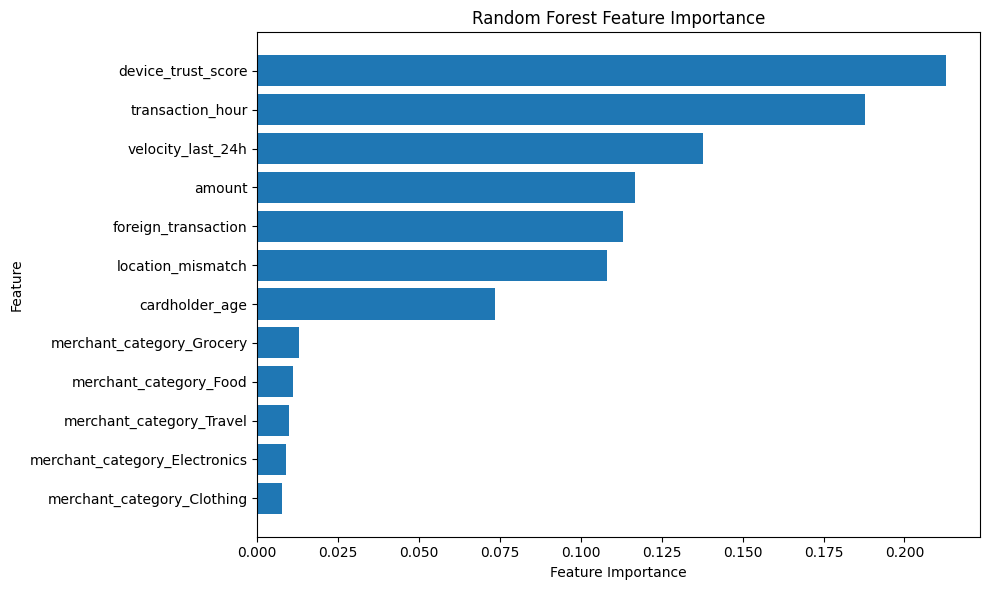

In [84]:
top_features = feature_importance.head(12)
plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.show()

## 15. XGBoost — Baseline

In [85]:
xgb_baseline = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_baseline.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [86]:
y_val_prob_xgb = xgb_baseline.predict_proba(
    X_val_processed
)[:, 1]

In [87]:
y_val_pred_xgb = (
    y_val_prob_xgb >= 0.5
).astype(int)

In [88]:
cm_xgb = confusion_matrix(
    y_val,
    y_val_pred_xgb
)

print("Confusion Matrix:")
print(cm_xgb)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb
    )
)

Confusion Matrix:
[[1477    0]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      1.00      1.00        23

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [89]:
roc_auc_xgb = roc_auc_score(
    y_val,
    y_val_prob_xgb
)

pr_auc_xgb = average_precision_score(
    y_val,
    y_val_prob_xgb
)

print("ROC-AUC:", roc_auc_xgb)
print("PR-AUC:", pr_auc_xgb)

ROC-AUC: 1.0
PR-AUC: 1.0


## 16. XGBoost — Threshold Optimization

In [90]:
precision_xgb, recall_xgb, thresholds_xgb = \
    precision_recall_curve(
        y_val,
        y_val_prob_xgb
    )

In [91]:
f1_xgb = (
    2 * precision_xgb[:-1]
    * recall_xgb[:-1]
    / (
        precision_xgb[:-1]
        + recall_xgb[:-1]
        + 1e-10
    )
)

In [92]:
best_idx_xgb = np.argmax(
    f1_xgb
)

best_threshold_xgb = \
    thresholds_xgb[best_idx_xgb]

print(
    "Best threshold:",
    best_threshold_xgb
)
print(
    "Precision:",
    precision_xgb[best_idx_xgb]
)
print(
    "Recall:",
    recall_xgb[best_idx_xgb]
)
print(
    "F1:",
    f1_xgb[best_idx_xgb]
)

Best threshold: 0.7502105
Precision: 1.0
Recall: 1.0
F1: 0.99999999995


In [93]:
y_val_pred_xgb_tuned = (
    y_val_prob_xgb >= best_threshold_xgb
).astype(int)

In [94]:
cm_xgb_tuned = confusion_matrix(
    y_val,
    y_val_pred_xgb_tuned
)

print("Confusion Matrix:")
print(cm_xgb_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb_tuned
    )
)

Confusion Matrix:
[[1477    0]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      1.00      1.00        23

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [95]:
roc_auc_xgb_tuned = roc_auc_score(
    y_val,
    y_val_prob_xgb
)

pr_auc_xgb_tuned = average_precision_score(
    y_val,
    y_val_prob_xgb
)

print("ROC-AUC:", roc_auc_xgb_tuned)
print("PR-AUC:", pr_auc_xgb_tuned)

ROC-AUC: 1.0
PR-AUC: 1.0


## 17. XGBoost + Imbalance Handling

In [96]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 65.0377358490566


In [97]:
xgb_balanced = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=65.04,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)
xgb_balanced.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [98]:
y_val_prob_xgb_balanced = xgb_balanced.predict_proba(
    X_val_processed
)[:, 1]

In [99]:
y_val_pred_xgb_balanced = (
    y_val_prob_xgb_balanced >= 0.5
).astype(int)

In [100]:
cm_xgb_balanced = confusion_matrix(
    y_val,
    y_val_pred_xgb_balanced
)

print("Confusion Matrix:")
print(cm_xgb_balanced)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb_balanced
    )
)

Confusion Matrix:
[[1477    0]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      1.00      1.00        23

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [101]:
roc_auc_xgb_balanced = roc_auc_score(
    y_val,
    y_val_prob_xgb_balanced
)

pr_auc_xgb_balanced = average_precision_score(
    y_val,
    y_val_prob_xgb_balanced
)

print("ROC-AUC:", roc_auc_xgb_balanced)
print("PR-AUC:", pr_auc_xgb_balanced)

ROC-AUC: 1.0
PR-AUC: 0.9999999999999998


## 18. Balanced XGBoost + Threshold Optimization

In [102]:
precision_xgb_balanced, recall_xgb_balanced, thresholds_xgb_balanced = \
    precision_recall_curve(
        y_val,
        y_val_prob_xgb_balanced
    )

In [103]:
f1_xgb_balanced = (
    2 * precision_xgb_balanced[:-1]
    * recall_xgb_balanced[:-1]
    / (
        precision_xgb_balanced[:-1]
        + recall_xgb_balanced[:-1]
        + 1e-10
    )
)

In [104]:
best_idx_xgb_balanced = np.argmax(
    f1_xgb_balanced
)

best_threshold_xgb_balanced = \
    thresholds_xgb_balanced[best_idx_xgb_balanced]

print(
    "Best threshold:",
    best_threshold_xgb_balanced
)
print(
    "Precision:",
    precision_xgb_balanced[best_idx_xgb_balanced]
)
print(
    "Recall:",
    recall_xgb_balanced[best_idx_xgb_balanced]
)
print(
    "F1:",
    f1_xgb_balanced[best_idx_xgb_balanced]
)

Best threshold: 0.9982274
Precision: 1.0
Recall: 1.0
F1: 0.99999999995


In [105]:
y_val_pred_xgb_balanced_tuned = (
    y_val_prob_xgb_balanced >= best_threshold_xgb_balanced
).astype(int)

In [106]:
cm_xgb_balanced_tuned = confusion_matrix(
    y_val,
    y_val_pred_xgb_balanced_tuned
)

print("Confusion Matrix:")
print(cm_xgb_balanced_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb_balanced_tuned
    )
)

Confusion Matrix:
[[1477    0]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      1.00      1.00        23

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [107]:
roc_auc_xgb_balanced_tuned = roc_auc_score(
    y_val,
    y_val_prob_xgb_balanced
)

pr_auc_xgb_balanced_tuned = average_precision_score(
    y_val,
    y_val_prob_xgb_balanced
)

print("ROC-AUC:", roc_auc_xgb_balanced_tuned)
print("PR-AUC:", pr_auc_xgb_balanced_tuned)

ROC-AUC: 1.0
PR-AUC: 0.9999999999999998


## 19. XGBoost — Hyperparameter Tuning

In [108]:
xgb_param_grid = {
    "n_estimators": [200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 6, 8],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
    "gamma": [0, 0.1, 0.3]
}

In [109]:
xgb_tuned_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),
    param_distributions=xgb_param_grid,
    n_iter=20,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1
)

xgb_tuned_search.fit(
    X_train_processed,
    y_train
)

,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], ...}"
,n_iter,20
,scoring,'average_precision'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [110]:
print("Best Parameters:")
print(xgb_tuned_search.best_params_)
print("\nBest CV PR-AUC:")
print(xgb_tuned_search.best_score_)

Best Parameters:
{'subsample': 1.0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.8}

Best CV PR-AUC:
0.9946209439674485


In [111]:
xgb_tuned = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=3,
    min_child_weight=1,
    subsample=1.0,
    colsample_bytree=0.8,
    gamma=0.1,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_tuned.fit(
    X_train_processed,
    y_train
)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [112]:
y_val_prob_xgb_tuned = xgb_tuned.predict_proba(
    X_val_processed
)[:, 1]

In [113]:
y_val_pred_xgb_tuned = (
    y_val_prob_xgb_tuned >= 0.5
).astype(int)

In [114]:
cm_xgb_tuned = confusion_matrix(
    y_val,
    y_val_pred_xgb_tuned
)

print("Confusion Matrix:")
print(cm_xgb_tuned)
print("Classification Report:")
print(
    classification_report(
        y_val,
        y_val_pred_xgb_tuned
    )
)

Confusion Matrix:
[[1477    0]
 [   0   23]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1477
           1       1.00      1.00      1.00        23

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



In [115]:
roc_auc_xgb_tuned = roc_auc_score(
    y_val,
    y_val_prob_xgb_tuned
)

pr_auc_xgb_tuned = average_precision_score(
    y_val,
    y_val_prob_xgb_tuned
)

print("ROC-AUC:", roc_auc_xgb_tuned)
print("PR-AUC:", pr_auc_xgb_tuned)

ROC-AUC: 1.0
PR-AUC: 1.0
